# GC 1m Intrabar Backtest

This notebook mirrors the main GC breakout research flow, but it runs on the local minute-bar file `glbx-mdp3-20250330-20260329.ohlcv-1m.csv`. The minute data is cleaned with the same dominant-contract pipeline as the historical notebook, then replayed with the intrabar engine on adjusted minute bars so the strategy can be evaluated with the same analytics, sensitivity views, and now a month-based walk-forward OOS pass.

## Clarifications and Approved Decisions

- The data source is the local minute CSV, not `yfinance`.
- Minute rows with accepted bar `rtype` values are normalized into the historical research cleaning path before spread removal and dominant-contract selection.
- Session breakout logic and trailing-stop evaluation run on adjusted minute OHLC values from the continuous series.
- Positions are flattened at session end in this intrabar workflow, so the within-session P&L impact of the constant Panama adjustment offset cancels.
- Walk-forward OOS uses month-based windows instead of year-based windows so the one-year minute sample can support multiple folds.


## 0. Configuration

Strategy, cost, data-path, and walk-forward parameters live here. The sensitivity and OOS grids default to a deliberately compact shape so the notebook stays practical on a one-year minute sample.


In [67]:
import importlib
from pathlib import Path

from IPython.display import display

import gold_breakout_intrabar_recent as intrabar_recent

intrabar_recent = importlib.reload(intrabar_recent)
make_default_recent_intrabar_config = intrabar_recent.make_default_recent_intrabar_config
make_default_recent_intrabar_replay_config = intrabar_recent.make_default_recent_intrabar_replay_config
recent_intrabar_config_frame = intrabar_recent.recent_intrabar_config_frame
recent_intrabar_replay_config_frame = intrabar_recent.recent_intrabar_replay_config_frame

config = make_default_recent_intrabar_config(
    csv_path=Path("glbx-mdp3-20250330-20260329.ohlcv-1m.csv"),
    backtest_start_session_date="2025-03-30",
    max_ohlc_violations=0,
    min_session_volume=0,
    accepted_rtypes=(33, 34),
)

replay_config = make_default_recent_intrabar_replay_config(
    tp_sl_mode="prior_day_range",
    fixed_ticks=100,
    atr_multiplier_tpsl=2.0,
    k=0.75,
    atr_period=14,
    atr_multiplier=0.75,
    starting_capital=100_000.0,
    risk_free_rate=0.0,
    round_turn_cost=24.74,
    allow_independent_long_short=True,
    close_positions_at_session_end=True,
    sensitivity_atr_periods=(14,),
    sensitivity_atr_multipliers=(0.50, 0.75),
    sensitivity_ks=(0.50, 0.75),
    sensitivity_tp_sl_modes=("prior_day_range",),
    walk_forward_objective="sharpe_ratio",
    walk_forward_train_months=6,
    walk_forward_test_months=1,
    walk_forward_step_months=2,
    walk_forward_atr_periods=(14,),
    walk_forward_tp_sl_modes=("prior_day_range",),
    walk_forward_atr_multipliers=(0.50, 0.75),
    walk_forward_ks=(0.75,),
)

display(recent_intrabar_config_frame(config))
display(recent_intrabar_replay_config_frame(replay_config))


,parameter,value
0,csv_path,glbx-mdp3-20250330-20260329.ohlcv-1m.csv
1,backtest_start_session_date,2025-03-30
2,max_ohlc_violations,0
3,min_session_volume,0
4,accepted_rtypes,"(33, 34)"


,parameter,value
0,tp_sl_mode,prior_day_range
1,fixed_ticks,100
2,atr_multiplier_tpsl,2.0
3,k,0.75
4,atr_period,14
5,atr_multiplier,0.75
6,starting_capital,100000.0
7,risk_free_rate,0.0
8,round_turn_cost,24.74
9,allow_independent_long_short,True


## 1. Imports and Environment Setup

The helper module exposes the same kinds of entry points as the historical notebook: context building, feature preparation, backtest execution, sensitivity sweeps, plotting, and walk-forward analysis.


In [68]:
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

build_recent_intrabar_context = intrabar_recent.build_recent_intrabar_context
prepare_recent_intrabar_feature_data = intrabar_recent.prepare_recent_intrabar_feature_data
preview_intrabar_signal_inputs = intrabar_recent.preview_intrabar_signal_inputs
recent_intrabar_data_paths = intrabar_recent.recent_intrabar_data_paths
run_recent_intrabar_backtest = intrabar_recent.run_recent_intrabar_backtest
run_recent_intrabar_sensitivity_analysis = intrabar_recent.run_recent_intrabar_sensitivity_analysis
run_recent_intrabar_walk_forward_analysis = intrabar_recent.run_recent_intrabar_walk_forward_analysis
summarize_intrabar_audit = intrabar_recent.summarize_intrabar_audit
plot_directional_drawdown_curves = intrabar_recent.plot_directional_drawdown_curves
plot_directional_equity_curves = intrabar_recent.plot_directional_equity_curves
plot_drawdown_curve = intrabar_recent.plot_drawdown_curve
plot_equity_curve = intrabar_recent.plot_equity_curve
plot_exit_reason_breakdown = intrabar_recent.plot_exit_reason_breakdown
plot_heatmap_grid = intrabar_recent.plot_heatmap_grid
plot_monthly_returns_heatmap = intrabar_recent.plot_monthly_returns_heatmap
plot_session_replay = intrabar_recent.plot_session_replay
plot_trade_pnl_distribution = intrabar_recent.plot_trade_pnl_distribution
plot_trail_sensitivity_curve = intrabar_recent.plot_trail_sensitivity_curve

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 120


## 2. Data Ingestion and Validation

The minute CSV is schema-checked, filtered to accepted minute-bar row types, cleaned for spreads and duplicates, and audited before the dominant-contract continuous series is built.


In [69]:
context = build_recent_intrabar_context(config)
data_paths = recent_intrabar_data_paths(config)

display(pd.DataFrame([context["metadata"]]))
display(pd.DataFrame({"path_key": list(data_paths.keys()), "path": [str(path) for path in data_paths.values()]}))
display(pd.DataFrame({"note": context["notes"]}))
display(summarize_intrabar_audit(context["audit"]))
display(context["audit"]["frames"]["excluded_spreads"].head(10))
display(context["audit"]["frames"]["duplicate_resolution"].head(10))
display(context["audit"]["frames"]["low_volume_sessions_all_outrights"].head(10))


,source,csv_path,rows_raw,rows_after_rtype_filter,accepted_rtypes,ts_min,ts_max,backtest_start_session_date,rows_clean,rows_continuous,rows_minute_bars,session_count,dominant_contracts
0,local_csv,glbx-mdp3-20250330-20260329.ohlcv-1m.csv,1488270,1488270,"[33, 34]",2025-03-30T22:00:00+00:00,2026-03-29T23:59:00+00:00,2025-03-30,800952,352404,352404,260,6


,path_key,path
0,csv_path,glbx-mdp3-20250330-20260329.ohlcv-1m.csv


,note
0,Minute data comes from the local Databento-sty...
1,Rows with accepted minute-bar rtypes are norma...
2,Intrabar replay runs on adjusted minute OHLC v...
3,The forward-filled hourly table is a diagnosti...


,metric,value
0,raw_rows,1488270
1,excluded_non_rtype_34,0
2,excluded_spread_rows,687318
3,ohlc_violation_count,0
4,duplicate_ts_instrument_rows,0
5,zero_volume_bar_count,0
6,low_liquidity_bar_count,253151
7,session_count_all_outrights,260


,symbol
30117,GCF6-GCG6
767231,GCF6-GCH6
328222,GCF6-GCJ6
84277,GCF6-GCK6
766766,GCF6-GCM6
767251,GCF6-GCN6
766797,GCF6-GCQ6
684222,GCF6-GCV6
712616,GCF6-GCZ6
1048827,GCF6-GCZ7


,ts_event,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol,is_spread,selected


,session_id,session_open_ts,session_close_ts,session_bars,session_date,session_open_hour_utc,session_close_hour_utc,previous_session_id,session_total_volume


## 3. Continuous Series Construction

The dominant contract is selected session by session, roll diagnostics are logged, and the minute replay engine receives adjusted minute bars from the resulting continuous series. A forward-filled hourly resample is also included as a diagnostic audit view.


In [70]:
display(context["session_table"].head(10))
display(context["audit"]["frames"]["roll_log"].head(10))
display(context["audit"]["frames"]["incomplete_or_irregular_sessions"].head(10))
display(context["hourly_bars"].head(10))
display(context["hourly_bars_forward_filled"].head(10))


,session_id,session_date,dominant_contract,dominant_volume,previous_dominant_contract,previous_dominant_volume,previous_session_id,roll_flag,session_open_ts,session_close_ts,session_bars,session_open_hour_utc,session_close_hour_utc,session_total_volume,continuous_session_bars,complete_session,first_bar_ts,last_bar_ts,first_close,last_close,first_open,outgoing_last_close,outgoing_last_bar_ts,roll_gap,roll_adjustment,adj_factor,previous_adj_factor,roll_continuity_error
0,0,2025-03-30 00:00:00+00:00,GCM5,198681,<NA>,NaN,NaN,False,2025-03-30 22:00:00+00:00,2025-03-31 20:59:00+00:00,1379,22,20,205403,1379,False,2025-03-30 22:00:00+00:00,2025-03-31 20:59:00+00:00,3120.2,3157.4,3118.8,NaN,NaT,0.0,0.0,178.1,NaN,0.0
1,1,2025-03-31 00:00:00+00:00,GCM5,184659,GCM5,198681.0,0.0,False,2025-03-31 22:00:00+00:00,2025-04-01 20:59:00+00:00,1380,22,20,189913,1380,False,2025-03-31 22:00:00+00:00,2025-04-01 20:59:00+00:00,3157.7,3148.5,3157.3,3157.4,2025-03-31 20:59:00+00:00,0.0,0.0,178.1,178.1,0.0
2,2,2025-04-01 00:00:00+00:00,GCM5,202783,GCM5,184659.0,1.0,False,2025-04-01 22:00:00+00:00,2025-04-02 20:59:00+00:00,1380,22,20,209768,1380,False,2025-04-01 22:00:00+00:00,2025-04-02 20:59:00+00:00,3147.8,3190.3,3147.5,3148.5,2025-04-01 20:59:00+00:00,0.0,0.0,178.1,178.1,0.0
3,3,2025-04-02 00:00:00+00:00,GCM5,352526,GCM5,202783.0,2.0,False,2025-04-02 22:00:00+00:00,2025-04-03 20:59:00+00:00,1380,22,20,365722,1380,False,2025-04-02 22:00:00+00:00,2025-04-03 20:59:00+00:00,3174.5,3138.1,3196.6,3190.3,2025-04-02 20:59:00+00:00,0.0,0.0,178.1,178.1,0.0
4,4,2025-04-03 00:00:00+00:00,GCM5,298792,GCM5,352526.0,3.0,False,2025-04-03 22:00:00+00:00,2025-04-04 20:59:00+00:00,1380,22,20,308497,1380,False,2025-04-03 22:00:00+00:00,2025-04-04 20:59:00+00:00,3136.8,3056.1,3138.0,3138.1,2025-04-03 20:59:00+00:00,0.0,0.0,178.1,178.1,0.0
5,5,2025-04-06 00:00:00+00:00,GCM5,296107,GCM5,298792.0,4.0,False,2025-04-06 22:00:00+00:00,2025-04-07 20:59:00+00:00,1380,22,20,306044,1380,False,2025-04-06 22:00:00+00:00,2025-04-07 20:59:00+00:00,3047.9,2998.8,3055.1,3056.1,2025-04-04 20:59:00+00:00,0.0,0.0,178.1,178.1,0.0
6,6,2025-04-07 00:00:00+00:00,GCM5,184080,GCM5,296107.0,5.0,False,2025-04-07 22:00:00+00:00,2025-04-08 20:59:00+00:00,1380,22,20,188440,1380,False,2025-04-07 22:00:00+00:00,2025-04-08 20:59:00+00:00,2998.3,2998.3,2997.5,2998.8,2025-04-07 20:59:00+00:00,0.0,0.0,178.1,178.1,0.0
7,7,2025-04-08 00:00:00+00:00,GCM5,281644,GCM5,184080.0,6.0,False,2025-04-08 22:00:00+00:00,2025-04-09 20:59:00+00:00,1380,22,20,289944,1380,False,2025-04-08 22:00:00+00:00,2025-04-09 20:59:00+00:00,2999.2,3099.8,2998.3,2998.3,2025-04-08 20:59:00+00:00,0.0,0.0,178.1,178.1,0.0
8,8,2025-04-09 00:00:00+00:00,GCM5,220343,GCM5,281644.0,7.0,False,2025-04-09 22:00:00+00:00,2025-04-10 20:59:00+00:00,1380,22,20,226278,1380,False,2025-04-09 22:00:00+00:00,2025-04-10 20:59:00+00:00,3096.7,3194.2,3099.1,3099.8,2025-04-09 20:59:00+00:00,0.0,0.0,178.1,178.1,0.0
9,9,2025-04-10 00:00:00+00:00,GCM5,233498,GCM5,220343.0,8.0,False,2025-04-10 22:00:00+00:00,2025-04-11 20:59:00+00:00,1380,22,20,239049,1380,False,2025-04-10 22:00:00+00:00,2025-04-11 20:59:00+00:00,3195.8,3254.9,3194.2,3194.2,2025-04-10 20:59:00+00:00,0.0,0.0,178.1,178.1,0.0


,session_id,session_date,previous_dominant_contract,dominant_contract,previous_dominant_volume,dominant_volume,roll_gap,roll_continuity_error
41,41,2025-05-27 00:00:00+00:00,GCM5,GCQ5,159196.0,124048,-29.6,0.0
85,85,2025-07-28 00:00:00+00:00,GCQ5,GCZ5,129777.0,100888,-54.8,0.0
170,170,2025-11-24 00:00:00+00:00,GCZ5,GCG6,159875.0,151859,-35.1,0.0
215,215,2026-01-27 00:00:00+00:00,GCG6,GCJ6,240354.0,335433,-25.6,0.0
258,258,2026-03-26 00:00:00+00:00,GCJ6,GCM6,166626.0,149437,-33.0,0.0


,session_id,session_date,continuous_session_bars,dominant_contract,session_total_volume
0,0,2025-03-30 00:00:00+00:00,1379,GCM5,205403
1,1,2025-03-31 00:00:00+00:00,1380,GCM5,189913
2,2,2025-04-01 00:00:00+00:00,1380,GCM5,209768
3,3,2025-04-02 00:00:00+00:00,1380,GCM5,365722
4,4,2025-04-03 00:00:00+00:00,1380,GCM5,308497
5,5,2025-04-06 00:00:00+00:00,1380,GCM5,306044
6,6,2025-04-07 00:00:00+00:00,1380,GCM5,188440
7,7,2025-04-08 00:00:00+00:00,1380,GCM5,289944
8,8,2025-04-09 00:00:00+00:00,1380,GCM5,226278
9,9,2025-04-10 00:00:00+00:00,1380,GCM5,239049


,session_id,session_date,ts_event,minute_count,open,high,low,close,adj_close,volume
0,0,2025-03-30 00:00:00+00:00,2025-03-30 22:00:00+00:00,60,3296.9,3306.4,3296.6,3301.1,3301.1,6480
1,0,2025-03-30 00:00:00+00:00,2025-03-30 23:00:00+00:00,60,3301.3,3303.0,3300.1,3301.6,3301.6,2166
2,0,2025-03-30 00:00:00+00:00,2025-03-31 00:00:00+00:00,60,3301.5,3302.0,3290.6,3292.8,3292.8,4712
3,0,2025-03-30 00:00:00+00:00,2025-03-31 01:00:00+00:00,60,3292.9,3307.2,3290.5,3305.7,3305.7,7944
4,0,2025-03-30 00:00:00+00:00,2025-03-31 02:00:00+00:00,60,3305.6,3318.3,3304.8,3316.9,3316.9,13279
5,0,2025-03-30 00:00:00+00:00,2025-03-31 03:00:00+00:00,60,3316.8,3321.7,3315.7,3317.1,3317.1,5409
6,0,2025-03-30 00:00:00+00:00,2025-03-31 04:00:00+00:00,60,3317.1,3325.1,3316.1,3323.3,3323.3,3913
7,0,2025-03-30 00:00:00+00:00,2025-03-31 05:00:00+00:00,60,3323.1,3330.5,3317.3,3327.3,3327.3,6453
8,0,2025-03-30 00:00:00+00:00,2025-03-31 06:00:00+00:00,60,3327.1,3336.3,3322.7,3327.4,3327.4,10058
9,0,2025-03-30 00:00:00+00:00,2025-03-31 07:00:00+00:00,60,3327.5,3335.0,3327.1,3334.8,3334.8,8418


,session_id,session_date,ts_event,minute_count,open,high,low,close,adj_close,volume,forward_filled
0,0,2025-03-30 00:00:00+00:00,2025-03-30 22:00:00+00:00,60,3296.9,3306.4,3296.6,3301.1,3301.1,6480,False
1,0,2025-03-30 00:00:00+00:00,2025-03-30 23:00:00+00:00,60,3301.3,3303.0,3300.1,3301.6,3301.6,2166,False
2,0,2025-03-30 00:00:00+00:00,2025-03-31 00:00:00+00:00,60,3301.5,3302.0,3290.6,3292.8,3292.8,4712,False
3,0,2025-03-30 00:00:00+00:00,2025-03-31 01:00:00+00:00,60,3292.9,3307.2,3290.5,3305.7,3305.7,7944,False
4,0,2025-03-30 00:00:00+00:00,2025-03-31 02:00:00+00:00,60,3305.6,3318.3,3304.8,3316.9,3316.9,13279,False
5,0,2025-03-30 00:00:00+00:00,2025-03-31 03:00:00+00:00,60,3316.8,3321.7,3315.7,3317.1,3317.1,5409,False
6,0,2025-03-30 00:00:00+00:00,2025-03-31 04:00:00+00:00,60,3317.1,3325.1,3316.1,3323.3,3323.3,3913,False
7,0,2025-03-30 00:00:00+00:00,2025-03-31 05:00:00+00:00,60,3323.1,3330.5,3317.3,3327.3,3327.3,6453,False
8,0,2025-03-30 00:00:00+00:00,2025-03-31 06:00:00+00:00,60,3327.1,3336.3,3322.7,3327.4,3327.4,10058,False
9,0,2025-03-30 00:00:00+00:00,2025-03-31 07:00:00+00:00,60,3327.5,3335.0,3327.1,3334.8,3334.8,8418,False


## 4. Feature Engineering

This stage attaches prior-session breakout levels, previous-session range, minute true range, shifted ATR, and the active stop distance for the current configuration.


In [71]:
feature_data = prepare_recent_intrabar_feature_data(context, replay_config)

feature_data[
    [
        "ts_event",
        "session_id",
        "session_date",
        "dominant_contract",
        "open",
        "high",
        "low",
        "close",
        "prev_session_high",
        "prev_session_low",
        "prev_session_range",
        "true_range",
        "atr",
        "sl_distance_price",
    ]
].head(15)


,ts_event,session_id,session_date,dominant_contract,open,high,low,close,prev_session_high,prev_session_low,prev_session_range,true_range,atr,sl_distance_price
0,2025-03-30 22:00:00+00:00,0,2025-03-30 00:00:00+00:00,GCM5,3296.9,3298.8,3296.6,3298.3,NaN,NaN,NaN,2.2,NaN,NaN
1,2025-03-30 22:01:00+00:00,0,2025-03-30 00:00:00+00:00,GCM5,3297.8,3300.8,3297.7,3300.4,NaN,NaN,NaN,3.1,NaN,NaN
2,2025-03-30 22:02:00+00:00,0,2025-03-30 00:00:00+00:00,GCM5,3300.6,3302.7,3300.6,3301.1,NaN,NaN,NaN,2.3,NaN,NaN
3,2025-03-30 22:03:00+00:00,0,2025-03-30 00:00:00+00:00,GCM5,3300.7,3301.7,3299.5,3301.0,NaN,NaN,NaN,2.2,NaN,NaN
4,2025-03-30 22:04:00+00:00,0,2025-03-30 00:00:00+00:00,GCM5,3301.1,3302.0,3300.5,3300.8,NaN,NaN,NaN,1.5,NaN,NaN
5,2025-03-30 22:05:00+00:00,0,2025-03-30 00:00:00+00:00,GCM5,3301.0,3301.4,3300.2,3301.1,NaN,NaN,NaN,1.2,NaN,NaN
6,2025-03-30 22:06:00+00:00,0,2025-03-30 00:00:00+00:00,GCM5,3300.8,3303.5,3300.2,3302.7,NaN,NaN,NaN,3.3,NaN,NaN
7,2025-03-30 22:07:00+00:00,0,2025-03-30 00:00:00+00:00,GCM5,3302.7,3303.6,3302.1,3303.4,NaN,NaN,NaN,1.5,NaN,NaN
8,2025-03-30 22:08:00+00:00,0,2025-03-30 00:00:00+00:00,GCM5,3303.2,3306.4,3303.2,3306.2,NaN,NaN,NaN,3.2,NaN,NaN
9,2025-03-30 22:09:00+00:00,0,2025-03-30 00:00:00+00:00,GCM5,3306.3,3306.4,3304.7,3304.7,NaN,NaN,NaN,1.7,NaN,NaN


## 5. Signal Generation

Orders are still session-open breakouts. This preview makes the daily setup auditable before the minute-by-minute engine runs.


In [72]:
signal_preview = preview_intrabar_signal_inputs(context, replay_config, rows=15)
signal_preview


,ts_event,session_id,session_date,buy_stop,sell_stop,prev_session_range,atr,sl_distance_price,open,high,low,close,volume
0,2025-03-30 22:00:00+00:00,0,2025-03-30 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,3296.9,3298.8,3296.6,3298.3,539
1,2025-03-31 22:00:00+00:00,1,2025-03-31 00:00:00+00:00,3340.1,3290.5,49.6,0.507126,37.200,3335.4,3335.8,3334.5,3335.8,122
2,2025-04-01 22:00:00+00:00,2,2025-04-01 00:00:00+00:00,3355.1,3308.6,46.5,0.678494,34.875,3325.6,3326.3,3324.8,3325.9,173
3,2025-04-02 22:00:00+00:00,3,2025-04-02 00:00:00+00:00,3379.7,3313.8,65.9,4.998001,49.425,3374.7,3374.7,3349.7,3352.6,1280
4,2025-04-03 22:00:00+00:00,4,2025-04-03 00:00:00+00:00,3374.7,3251.6,123.1,1.202472,92.325,3316.1,3316.4,3314.1,3314.9,89
5,2025-04-06 22:00:00+00:00,5,2025-04-06 00:00:00+00:00,3338.3,3210.8,127.5,1.077059,95.625,3233.2,3233.2,3183.6,3226.0,987
6,2025-04-07 22:00:00+00:00,6,2025-04-07 00:00:00+00:00,3262.5,3148.5,114.0,0.982611,85.500,3175.6,3177.2,3175.5,3176.4,104
7,2025-04-08 22:00:00+00:00,7,2025-04-08 00:00:00+00:00,3216.0,3166.7,49.3,0.710329,36.975,3176.4,3177.4,3175.6,3177.3,133
8,2025-04-09 22:00:00+00:00,8,2025-04-09 00:00:00+00:00,3296.6,3161.4,135.2,1.453822,101.400,3277.2,3278.1,3273.6,3274.8,119
9,2025-04-10 22:00:00+00:00,9,2025-04-10 00:00:00+00:00,3373.1,3264.2,108.9,0.954517,81.675,3372.3,3375.8,3371.5,3373.9,210


## 6. Portfolio and Execution Engine

The intrabar engine steps through each minute bar, supports independent long and short entries when enabled, and records a full event log plus backtest-style analytics.


In [73]:
backtest_start = perf_counter()
result = run_recent_intrabar_backtest(context, replay_config)
backtest_elapsed = perf_counter() - backtest_start
print(f"Backtest runtime: {backtest_elapsed:.2f} seconds")

display(result.trade_log.head(10))
display(result.event_log.head(10))
display(result.skipped_sessions.head(10))


Backtest runtime: 23.79 seconds


,trade_id,session_id,session_date,direction,entry_ts,entry_bar_ts,entry_price,tp_price,initial_sl_price,exit_ts,exit_bar_ts,exit_price,exit_reason,exit_fill_basis,bars_held,pnl_usd,gross_pnl,trade_cost,net_pnl,mfe_price,mae_price,mfe_usd,mae_usd
0,1,1,2025-03-31 00:00:00+00:00,long,2025-04-01 00:56:00+00:00,2025-04-01 00:56:00+00:00,3340.2,3377.400,3303.000,2025-04-01 00:59:00+00:00,2025-04-01 00:59:00+00:00,3339.572805,trail_stop,stop_minus_tick_exit,3,-62.719545,-62.719545,24.74,-87.459545,0.0,0.6,0.0,60.0
1,2,2,2025-04-01 00:00:00+00:00,long,2025-04-02 16:26:00+00:00,2025-04-02 16:26:00+00:00,3355.2,3390.075,3320.325,2025-04-02 16:28:00+00:00,2025-04-02 16:28:00+00:00,3354.826936,trail_stop,stop_minus_tick_exit,2,-37.306391,-37.306391,24.74,-62.046391,0.6,0.6,60.0,60.0
2,3,3,2025-04-02 00:00:00+00:00,short,2025-04-03 10:08:00+00:00,2025-04-03 10:08:00+00:00,3313.7,3264.275,3363.125,2025-04-03 10:10:00+00:00,2025-04-03 10:10:00+00:00,3311.813402,trail_stop,stop_plus_tick_exit,2,188.659812,188.659812,24.74,163.919812,3.6,0.0,360.0,0.0
3,4,4,2025-04-03 00:00:00+00:00,short,2025-04-04 14:01:00+00:00,2025-04-04 14:01:00+00:00,3251.5,3159.175,3343.825,2025-04-04 14:04:00+00:00,2025-04-04 14:04:00+00:00,3252.389061,trail_stop,stop_plus_tick_exit,3,-88.906058,-88.906058,24.74,-113.646058,2.1,1.3,210.0,130.0
4,5,5,2025-04-06 00:00:00+00:00,short,2025-04-06 22:00:00+00:00,2025-04-06 22:00:00+00:00,3210.7,3115.075,3306.325,2025-04-06 22:02:00+00:00,2025-04-06 22:02:00+00:00,3214.260809,trail_stop,stop_plus_tick_exit,2,-356.080872,-356.080872,24.74,-380.820872,0.0,16.2,0.0,1620.0
5,6,7,2025-04-08 00:00:00+00:00,short,2025-04-08 23:35:00+00:00,2025-04-08 23:35:00+00:00,3166.6,3129.625,3203.575,2025-04-08 23:37:00+00:00,2025-04-08 23:37:00+00:00,3165.878762,trail_stop,stop_plus_tick_exit,2,72.123786,72.123786,24.74,47.383786,2.2,0.5,220.0,50.0
6,7,7,2025-04-08 00:00:00+00:00,long,2025-04-09 05:15:00+00:00,2025-04-09 05:15:00+00:00,3216.1,3253.075,3179.125,2025-04-09 05:17:00+00:00,2025-04-09 05:17:00+00:00,3214.598188,trail_stop,stop_minus_tick_exit,2,-150.181189,-150.181189,24.74,-174.921189,0.6,6.2,60.0,620.0
7,8,8,2025-04-09 00:00:00+00:00,long,2025-04-10 02:06:00+00:00,2025-04-10 02:06:00+00:00,3296.7,3398.100,3195.300,2025-04-10 02:08:00+00:00,2025-04-10 02:08:00+00:00,3294.354904,trail_stop,stop_minus_tick_exit,2,-234.509602,-234.509602,24.74,-259.249602,0.0,5.6,0.0,560.0
8,9,9,2025-04-10 00:00:00+00:00,long,2025-04-10 22:00:00+00:00,2025-04-10 22:00:00+00:00,3373.2,3454.875,3291.525,2025-04-10 22:02:00+00:00,2025-04-10 22:02:00+00:00,3374.004890,trail_stop,stop_minus_tick_exit,2,80.488966,80.488966,24.74,55.748966,1.8,0.8,180.0,80.0
9,10,12,2025-04-15 00:00:00+00:00,long,2025-04-15 22:29:00+00:00,2025-04-15 22:29:00+00:00,3429.1,3448.150,3410.050,2025-04-15 22:31:00+00:00,2025-04-15 22:31:00+00:00,3429.569092,trail_stop,stop_minus_tick_exit,2,46.909184,46.909184,24.74,22.169184,1.1,0.6,110.0,60.0


,session_id,session_date,ts_event,trade_id,direction,event_type,event_reason,price
0,1,2025-03-31 00:00:00+00:00,2025-04-01 00:56:00+00:00,1,long,entry,buy_stop_trigger,3340.200000
1,1,2025-03-31 00:00:00+00:00,2025-04-01 00:59:00+00:00,1,long,exit,trail_stop,3339.572805
2,2,2025-04-01 00:00:00+00:00,2025-04-02 16:26:00+00:00,2,long,entry,buy_stop_trigger,3355.200000
3,2,2025-04-01 00:00:00+00:00,2025-04-02 16:28:00+00:00,2,long,exit,trail_stop,3354.826936
4,3,2025-04-02 00:00:00+00:00,2025-04-03 10:08:00+00:00,3,short,entry,sell_stop_trigger,3313.700000
5,3,2025-04-02 00:00:00+00:00,2025-04-03 10:10:00+00:00,3,short,exit,trail_stop,3311.813402
6,4,2025-04-03 00:00:00+00:00,2025-04-04 14:01:00+00:00,4,short,entry,sell_stop_trigger,3251.500000
7,4,2025-04-03 00:00:00+00:00,2025-04-04 14:04:00+00:00,4,short,exit,trail_stop,3252.389061
8,5,2025-04-06 00:00:00+00:00,2025-04-06 22:00:00+00:00,5,short,entry,sell_stop_trigger,3210.700000
9,5,2025-04-06 00:00:00+00:00,2025-04-06 22:02:00+00:00,5,short,exit,trail_stop,3214.260809


,session_id,session_date,ts_event,reason
0,0,2025-03-30 00:00:00+00:00,2025-03-30 22:00:00+00:00,Missing prior-session breakout inputs or stop-...


## 7. Transaction Cost Model

Each closed trade receives a flat round-turn cost so gross and net performance remain directly comparable.


In [74]:
cost_summary = result.performance_summary[
    [
        "gross_total_pnl",
        "net_total_pnl",
        "total_cost_drag",
        "cost_drag_pct_of_gross",
        "total_trades",
    ]
]

cost_summary.to_frame("value")


,value
gross_total_pnl,61545.774856
net_total_pnl,55385.514856
total_cost_drag,6160.260000
cost_drag_pct_of_gross,10.009233
total_trades,249.000000


## 8. Backtest Loop Diagnostics

These views expose the session-level replay summary, concurrency log, and frame-by-frame state recorded by the minute engine.


In [75]:
display(result.session_summary.head(10))
display(result.diagnostics["concurrency_log"].head(20))
display(result.frame_state.head(20))


,session_id,session_date,prev_session_high,prev_session_low,sl_distance_price,allow_independent_long_short,trade_count,entry_count,exit_count,net_pnl_usd
0,1,2025-03-31 00:00:00+00:00,3340.1,3290.5,37.200,True,1,1,1,-62.719545
1,2,2025-04-01 00:00:00+00:00,3355.1,3308.6,34.875,True,1,1,1,-37.306391
2,3,2025-04-02 00:00:00+00:00,3379.7,3313.8,49.425,True,1,1,1,188.659812
3,4,2025-04-03 00:00:00+00:00,3374.7,3251.6,92.325,True,1,1,1,-88.906058
4,5,2025-04-06 00:00:00+00:00,3338.3,3210.8,95.625,True,1,1,1,-356.080872
5,6,2025-04-07 00:00:00+00:00,3262.5,3148.5,85.500,True,0,0,0,0.000000
6,7,2025-04-08 00:00:00+00:00,3216.0,3166.7,36.975,True,2,2,2,-78.057404
7,8,2025-04-09 00:00:00+00:00,3296.6,3161.4,101.400,True,1,1,1,-234.509602
8,9,2025-04-10 00:00:00+00:00,3373.1,3264.2,81.675,True,1,1,1,80.488966
9,10,2025-04-13 00:00:00+00:00,3441.1,3371.5,52.200,True,0,0,0,0.000000


,session_id,ts_event,long_position_open,short_position_open,open_positions,simultaneous_long_short
0,1,2025-03-31 22:00:00+00:00,False,False,0,False
1,1,2025-03-31 22:01:00+00:00,False,False,0,False
2,1,2025-03-31 22:02:00+00:00,False,False,0,False
3,1,2025-03-31 22:03:00+00:00,False,False,0,False
4,1,2025-03-31 22:04:00+00:00,False,False,0,False
5,1,2025-03-31 22:05:00+00:00,False,False,0,False
6,1,2025-03-31 22:06:00+00:00,False,False,0,False
7,1,2025-03-31 22:07:00+00:00,False,False,0,False
8,1,2025-03-31 22:08:00+00:00,False,False,0,False
9,1,2025-03-31 22:09:00+00:00,False,False,0,False


,session_id,session_date,ts_event,bar_index,open,high,low,close,buy_stop,sell_stop,long_order_active,short_order_active,long_position_open,short_position_open,long_active_trail_stop,short_active_trail_stop,long_tp,short_tp,event_text
0,1,2025-03-31 00:00:00+00:00,2025-03-31 22:00:00+00:00,0,3335.4,3335.8,3334.5,3335.8,3340.1,3290.5,True,True,False,False,NaN,NaN,NaN,NaN,
1,1,2025-03-31 00:00:00+00:00,2025-03-31 22:01:00+00:00,1,3335.9,3336.4,3335.5,3336.3,3340.1,3290.5,True,True,False,False,NaN,NaN,NaN,NaN,
2,1,2025-03-31 00:00:00+00:00,2025-03-31 22:02:00+00:00,2,3336.2,3336.2,3335.7,3335.7,3340.1,3290.5,True,True,False,False,NaN,NaN,NaN,NaN,
3,1,2025-03-31 00:00:00+00:00,2025-03-31 22:03:00+00:00,3,3335.7,3335.7,3335.3,3335.6,3340.1,3290.5,True,True,False,False,NaN,NaN,NaN,NaN,
4,1,2025-03-31 00:00:00+00:00,2025-03-31 22:04:00+00:00,4,3335.9,3336.0,3335.7,3335.8,3340.1,3290.5,True,True,False,False,NaN,NaN,NaN,NaN,
5,1,2025-03-31 00:00:00+00:00,2025-03-31 22:05:00+00:00,5,3335.8,3336.5,3335.8,3336.2,3340.1,3290.5,True,True,False,False,NaN,NaN,NaN,NaN,
6,1,2025-03-31 00:00:00+00:00,2025-03-31 22:06:00+00:00,6,3336.2,3336.3,3336.0,3336.3,3340.1,3290.5,True,True,False,False,NaN,NaN,NaN,NaN,
7,1,2025-03-31 00:00:00+00:00,2025-03-31 22:07:00+00:00,7,3336.3,3336.6,3336.3,3336.6,3340.1,3290.5,True,True,False,False,NaN,NaN,NaN,NaN,
8,1,2025-03-31 00:00:00+00:00,2025-03-31 22:08:00+00:00,8,3336.6,3336.6,3336.2,3336.3,3340.1,3290.5,True,True,False,False,NaN,NaN,NaN,NaN,
9,1,2025-03-31 00:00:00+00:00,2025-03-31 22:09:00+00:00,9,3336.3,3336.4,3335.9,3336.0,3340.1,3290.5,True,True,False,False,NaN,NaN,NaN,NaN,


## 9. Performance Analytics

The summary includes return, drawdown, risk-adjusted metrics, benchmark comparison, direction splits, annual breakdown, and exit composition.


In [76]:
display(result.performance_summary.to_frame("value"))
display(result.benchmark_summary)
display(result.direction_summary)
display(result.annual_summary)
display(result.exit_breakdown)


,value
terminal_gross_equity,161545.774856
terminal_net_equity,155385.514856
total_return_pct,55.385515
annualized_return_pct,55.810586
max_drawdown_pct,1.242659
max_drawdown_duration_sessions,19.000000
sharpe_ratio,4.376962
sortino_ratio,23.717776
calmar_ratio,44.912247
total_trades,249.000000


,series,terminal_equity,total_return_pct,annualized_return_pct,max_drawdown_pct,sharpe_ratio,correlation_to_strategy
0,Strategy Net Equity,155385.514856,55.385515,55.810586,1.242659,4.376962,1.000000
1,GC Price Index,135733.559713,35.733560,35.990848,19.539118,1.228599,-0.228353


,direction,trades,win_rate_pct,gross_pnl,net_pnl,avg_win_usd,avg_loss_usd,profit_factor,avg_bars_held,avg_mfe_price,avg_mae_price,avg_mfe_usd,avg_mae_usd
0,long,144,53.472222,28642.586479,25080.026479,452.326069,-145.508670,4.539836,2.277778,3.795139,2.209722,379.513889,220.972222
1,short,105,45.714286,32903.188377,30305.488377,866.693335,-198.171784,4.328392,2.180952,6.322857,4.557143,632.285714,455.714286


,year,start_equity,end_equity,annual_return_pct,trade_count,win_rate_pct
0,2025,100000.000000,123736.026380,23.736026,191,47.643979
1,2026,123563.440837,155385.514856,25.753632,58,58.620690


,exit_reason,count,pct
0,trail_stop,249,100.0


## 10. Visualization

The chart set mirrors the historical notebook, adapted to the minute-based continuous series.


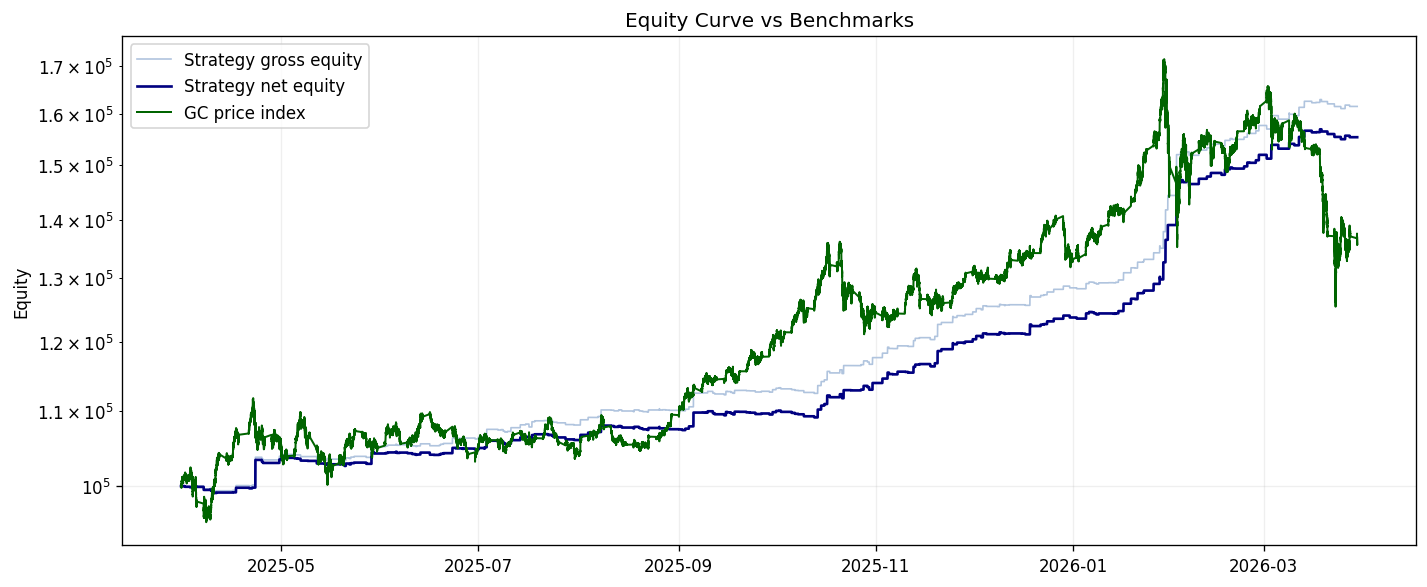

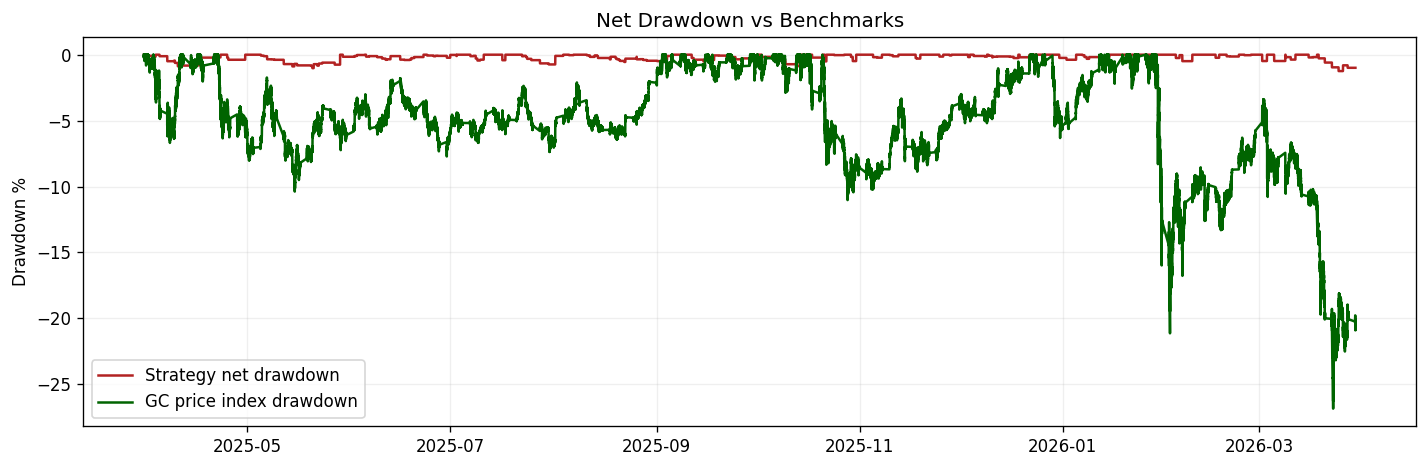

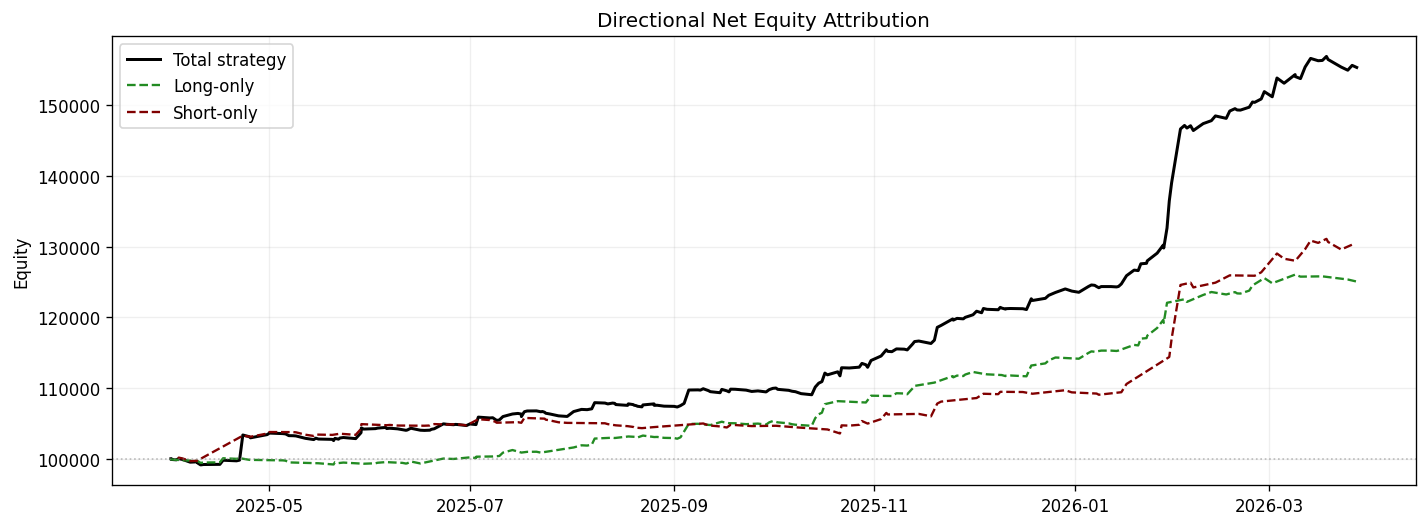

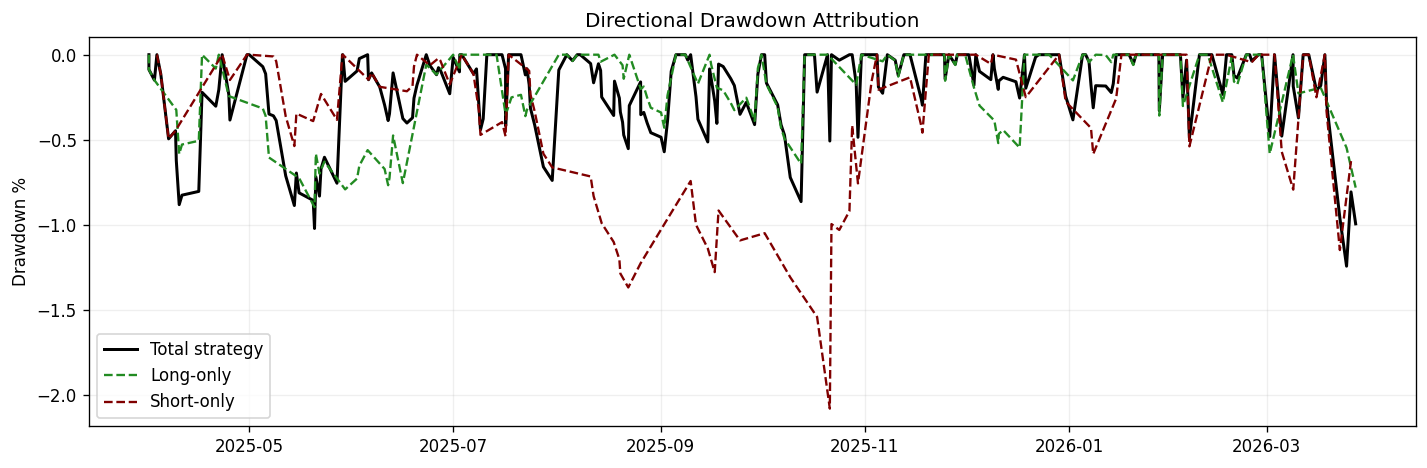

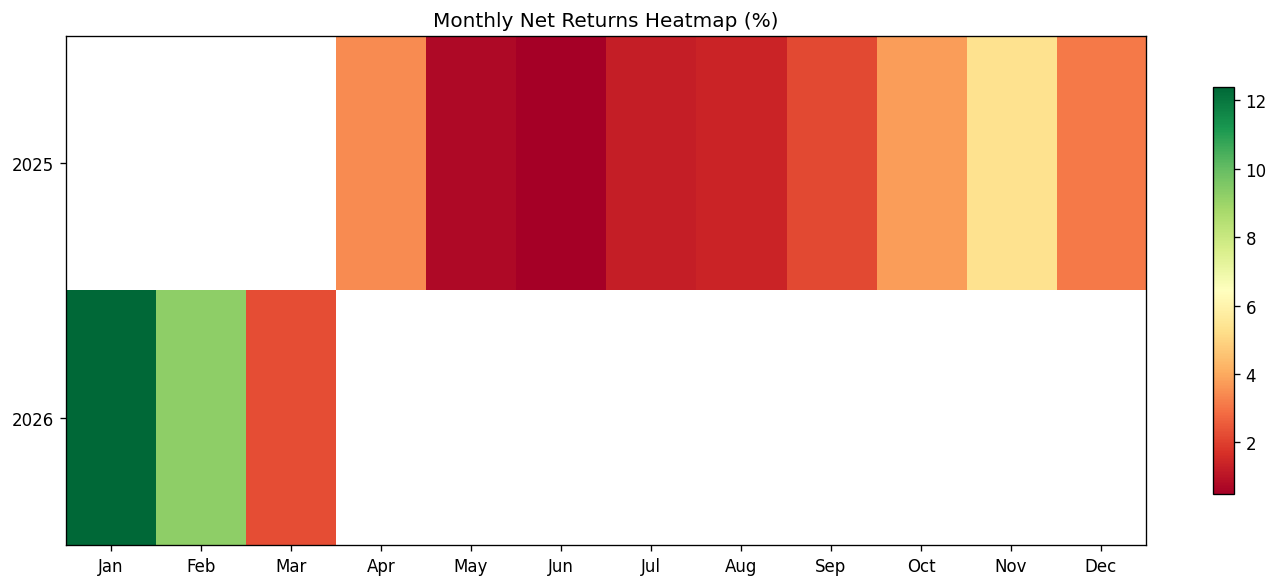

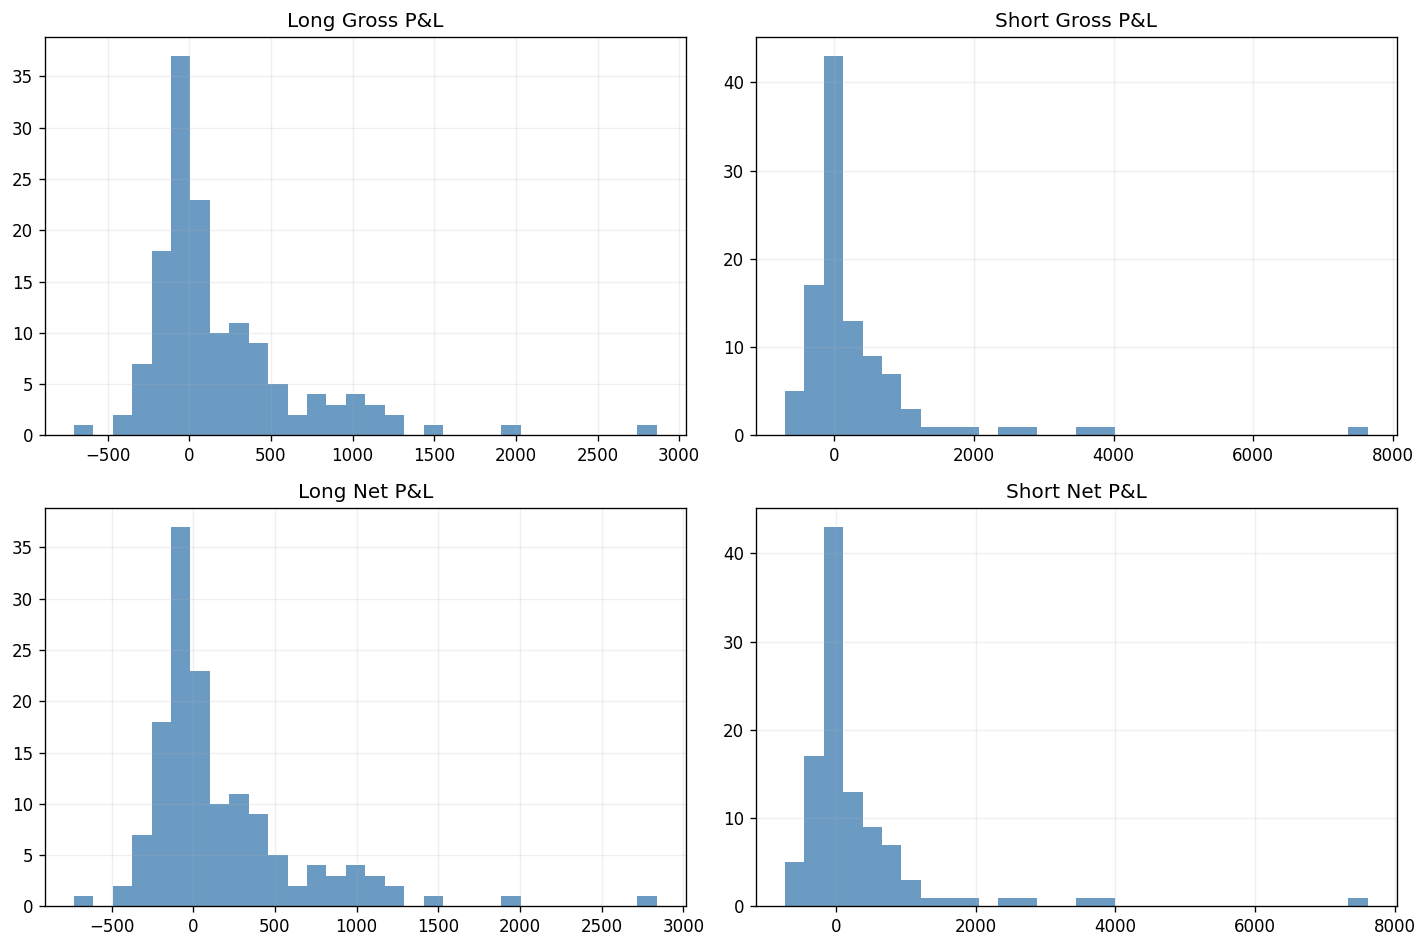

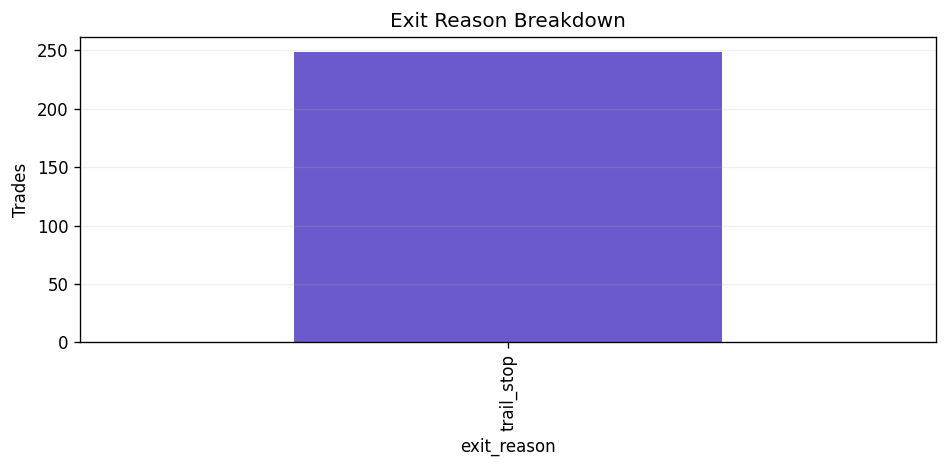

In [77]:
for figure in [
    plot_equity_curve(result),
    plot_drawdown_curve(result),
    plot_directional_equity_curves(result),
    plot_directional_drawdown_curves(result),
    plot_monthly_returns_heatmap(result),
    plot_trade_pnl_distribution(result),
    plot_exit_reason_breakdown(result),
]:
    display(figure)
    plt.close(figure)


## 11. Session Replay

The replay view reconstructs one traded session from the minute bars, event log, and evolving stop/target state so the strategy can be audited visually.


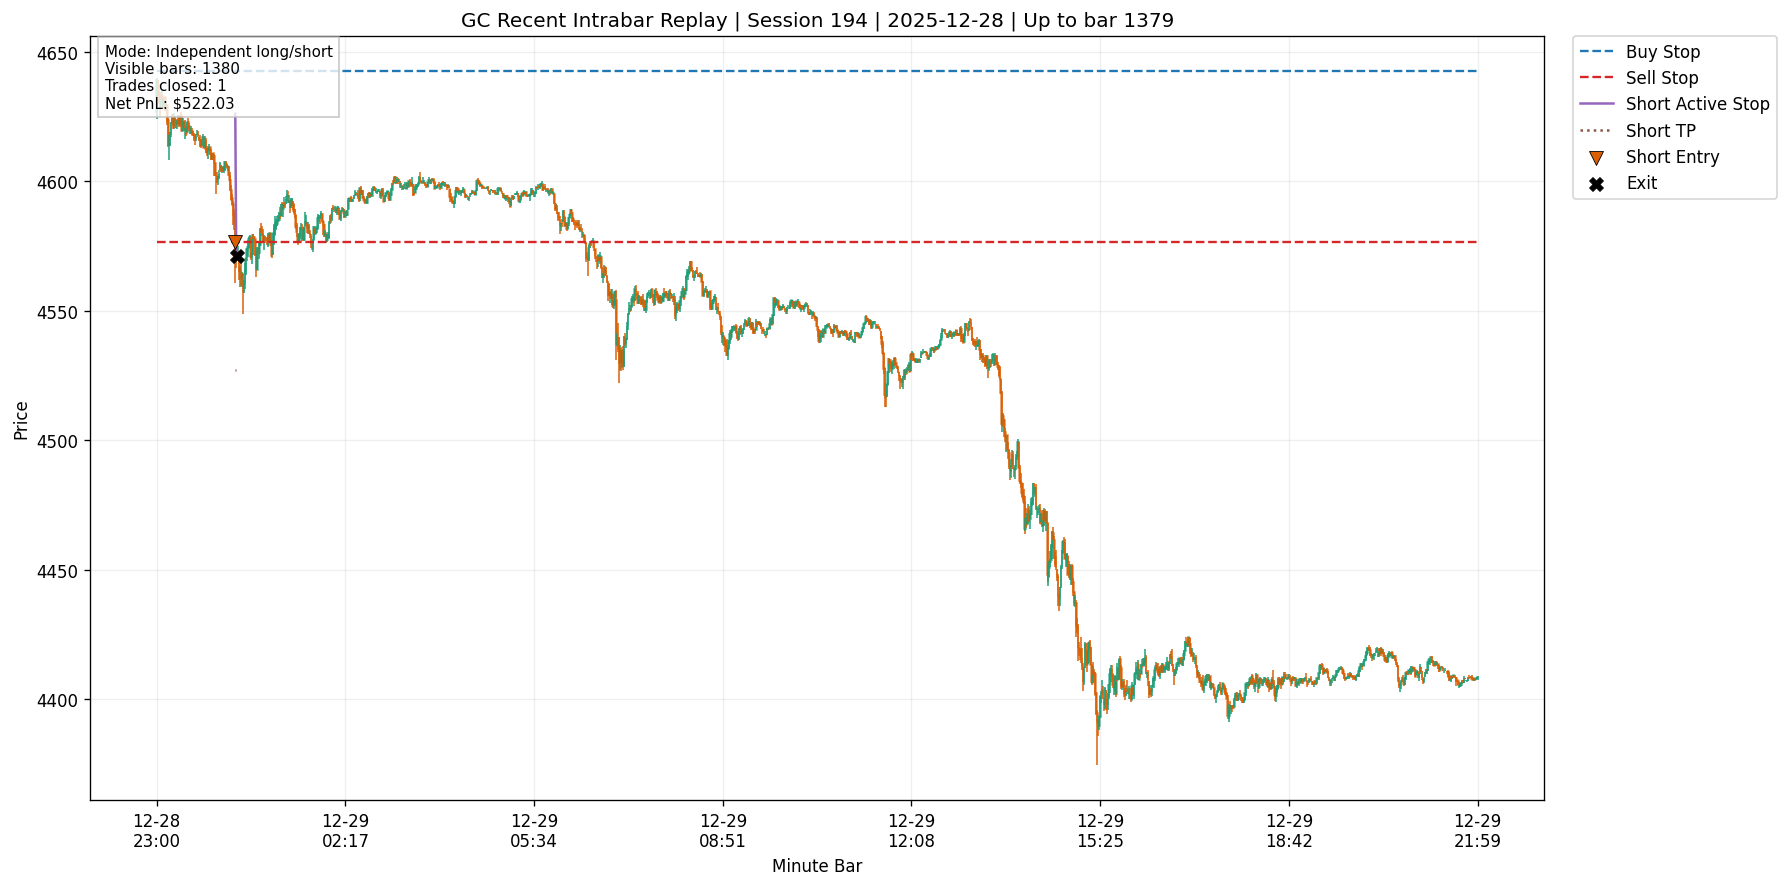

In [78]:
import random

trade_sessions = result.trade_log["session_id"].dropna().astype(int).unique().tolist()
replay_session_id = (
    trade_sessions[random.randint(0, len(trade_sessions) - 1)]
    if trade_sessions
    else int(result.session_table["session_id"].iloc[0])
)

figure = plot_session_replay(result, replay_session_id)
display(figure)
plt.close(figure)


## 12. Sensitivity Analysis

The default sensitivity grid is intentionally compact to keep notebook runtime reasonable on the one-year minute sample. A broad plateau still matters more than a single sharp optimum.


Sensitivity runtime: 95.12 seconds


,atr_period,tp_sl_mode,atr_multiplier,k,win_rate,profit_factor,sharpe_ratio,max_drawdown_pct,terminal_net_equity,total_return_pct,total_trades
0,14,prior_day_range,0.50,0.50,55.020080,6.056211,4.571900,2.166048,161834.006879,61.834007,249.0
1,14,prior_day_range,0.50,0.75,55.020080,7.206588,4.863950,1.039044,163980.638595,63.980639,249.0
2,14,prior_day_range,0.75,0.50,50.200803,3.967305,4.096491,2.655620,153318.067283,53.318067,249.0
3,14,prior_day_range,0.75,0.75,50.200803,4.423563,4.376962,1.242659,155385.514856,55.385515,249.0


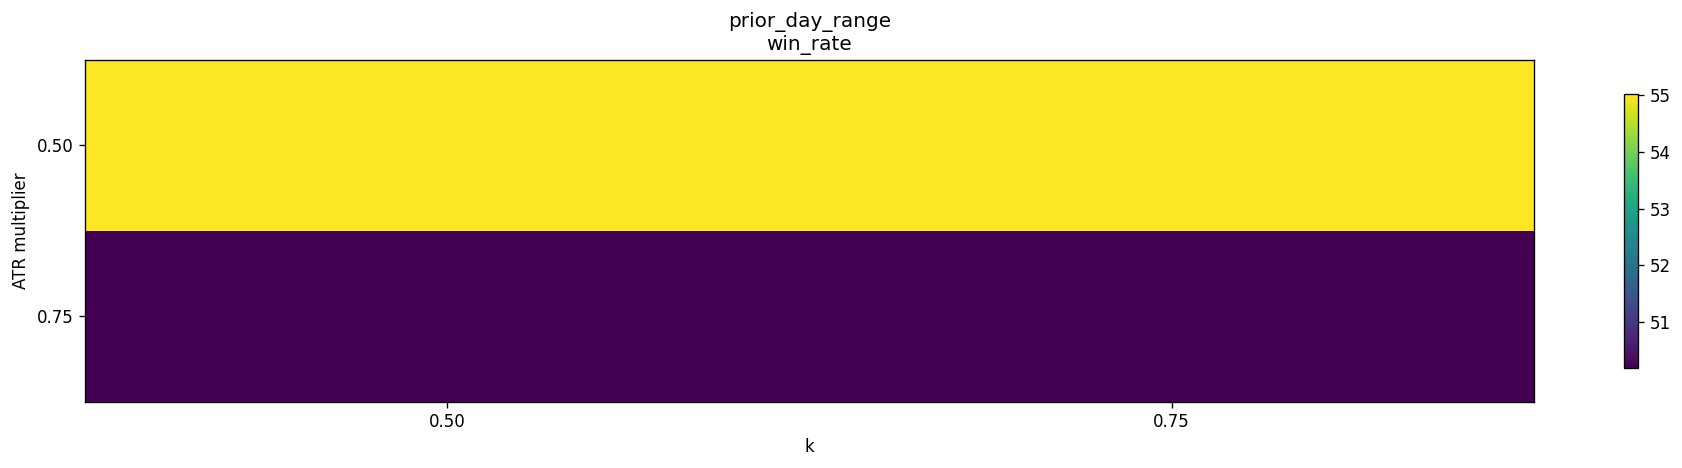

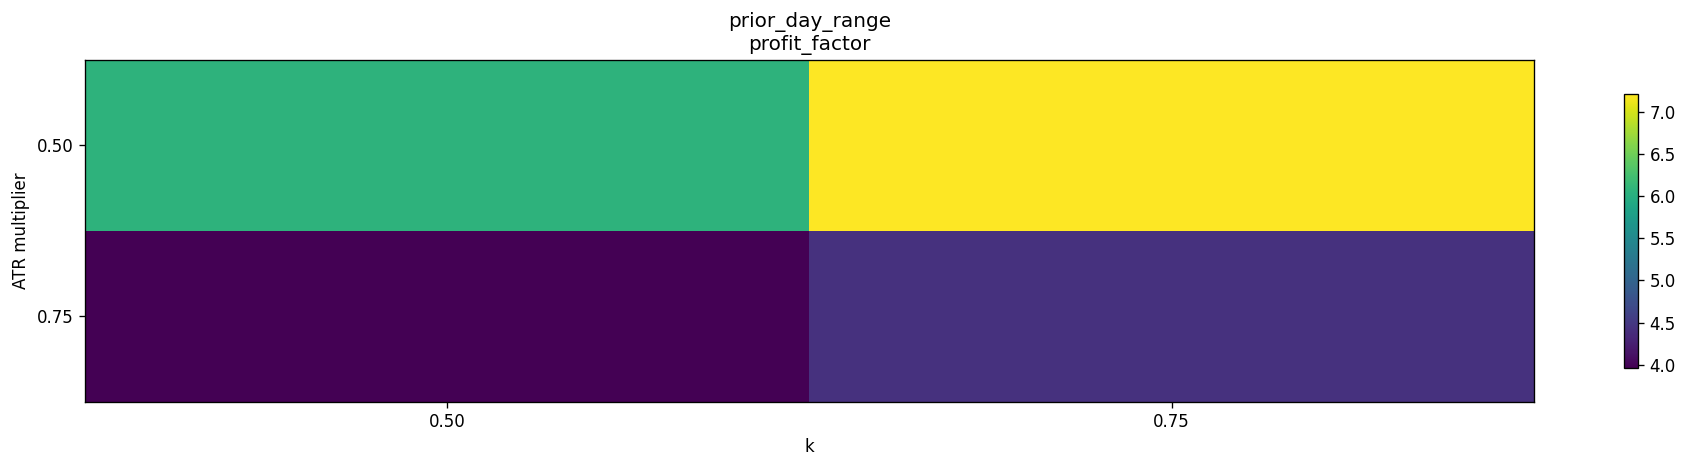

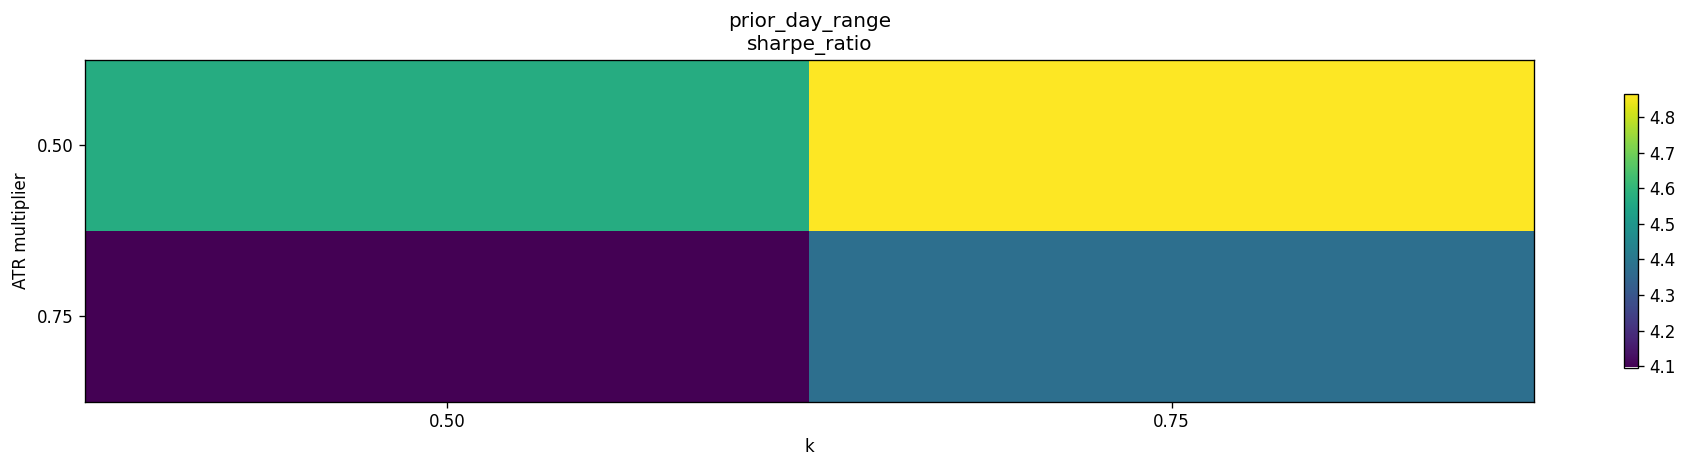

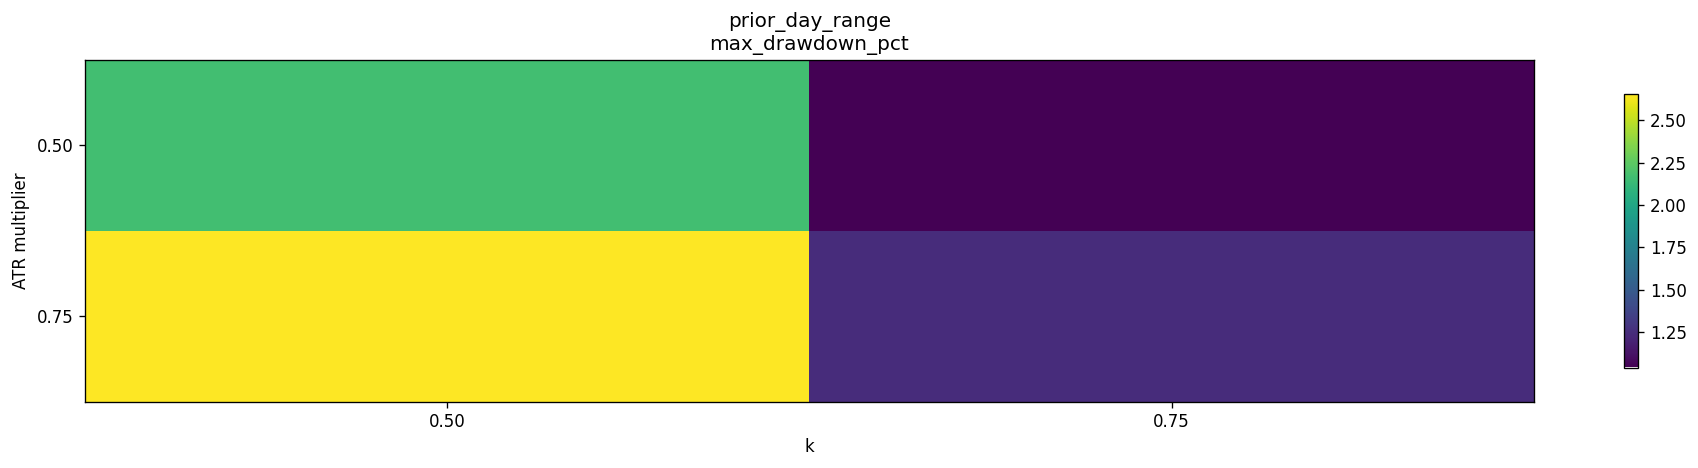

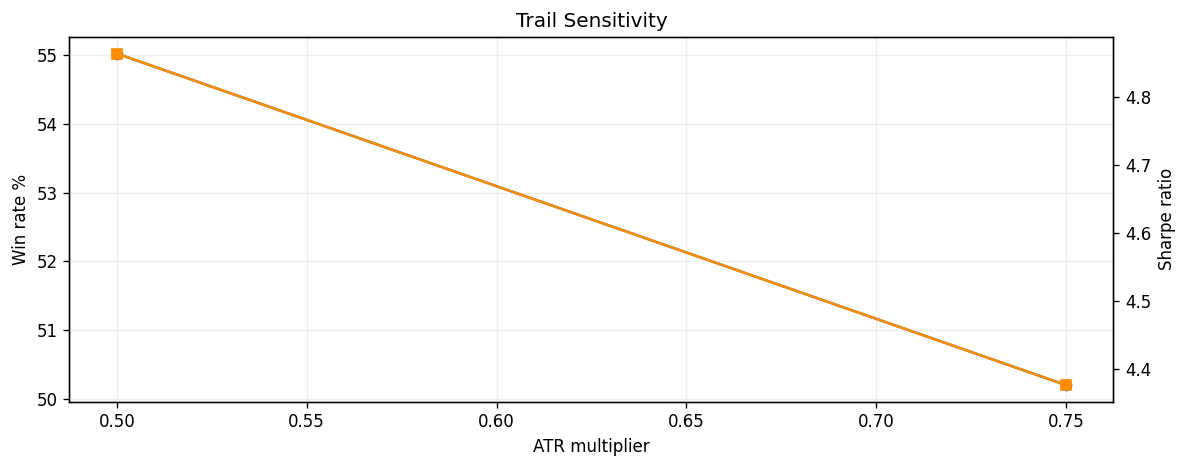

In [79]:
sensitivity_start = perf_counter()
sensitivity = run_recent_intrabar_sensitivity_analysis(context, replay_config)
sensitivity_elapsed = perf_counter() - sensitivity_start
print(f"Sensitivity runtime: {sensitivity_elapsed:.2f} seconds")

primary_grid = sensitivity["primary_grid"]

display(primary_grid.head(12))

for metric in ["win_rate", "profit_factor", "sharpe_ratio", "max_drawdown_pct"]:
    figure = plot_heatmap_grid(
        primary_grid,
        metric=metric,
        atr_period=replay_config.atr_period,
        tp_sl_modes=replay_config.sensitivity_tp_sl_modes,
    )
    display(figure)
    plt.close(figure)

figure = plot_trail_sensitivity_curve(primary_grid, replay_config)
display(figure)
plt.close(figure)


## 13. Walk-Forward OOS

The OOS pass uses month-based train/test windows so the one-year minute sample can support multiple folds without pretending we have a multi-year horizon. The optimization grid here is intentionally narrower than a full sensitivity sweep.


Walk-forward runtime: 79.17 seconds


,fold_id,train_start,train_end,test_start,test_end,train_sessions,test_sessions,objective,selected_atr_period,selected_tp_sl_mode,selected_atr_multiplier,selected_k,train_objective_value,train_sharpe_ratio,train_total_return_pct,train_max_drawdown_pct,train_total_trades,oos_sharpe_ratio,oos_total_return_pct,oos_max_drawdown_pct,oos_total_trades,oos_terminal_net_equity
0,1,2025-03-30 00:00:00+00:00,2025-09-30 00:00:00+00:00,2025-09-30 00:00:00+00:00,2025-10-30 00:00:00+00:00,131,22,sharpe_ratio,14,prior_day_range,0.5,0.75,3.959820,3.959820,13.573806,0.483255,128.0,5.592018,3.266721,0.558790,20.0,103266.720952
1,2,2025-05-30 00:00:00+00:00,2025-11-30 00:00:00+00:00,2025-11-30 00:00:00+00:00,2025-12-30 00:00:00+00:00,131,21,sharpe_ratio,14,prior_day_range,0.5,0.75,5.879327,5.879327,17.327129,0.520905,132.0,10.812231,4.115488,0.168619,19.0,104115.487511
2,3,2025-07-30 00:00:00+00:00,2026-01-30 00:00:00+00:00,2026-01-30 00:00:00+00:00,2026-02-28 00:00:00+00:00,131,21,sharpe_ratio,14,prior_day_range,0.5,0.75,5.793736,5.793736,36.202293,0.531727,132.0,12.209670,7.544256,0.454734,17.0,107544.256101


,parameter,value,selected_folds,selected_pct
0,atr_period,14,3,100.0
1,tp_sl_mode,prior_day_range,3,100.0
2,atr_multiplier,0.5,3,100.0
3,k,0.75,3,100.0


,fold_id,train_start,train_end,test_start,test_end,atr_period,tp_sl_mode,atr_multiplier,k,objective,train_objective_value,train_sharpe_ratio,train_total_return_pct,train_max_drawdown_pct,train_total_trades
0,1,2025-03-30 00:00:00+00:00,2025-09-30 00:00:00+00:00,2025-09-30 00:00:00+00:00,2025-10-30 00:00:00+00:00,14,prior_day_range,0.50,0.75,sharpe_ratio,3.959820,3.959820,13.573806,0.483255,128.0
1,1,2025-03-30 00:00:00+00:00,2025-09-30 00:00:00+00:00,2025-09-30 00:00:00+00:00,2025-10-30 00:00:00+00:00,14,prior_day_range,0.75,0.75,sharpe_ratio,2.785178,2.785178,9.788405,1.021060,128.0
2,2,2025-05-30 00:00:00+00:00,2025-11-30 00:00:00+00:00,2025-11-30 00:00:00+00:00,2025-12-30 00:00:00+00:00,14,prior_day_range,0.50,0.75,sharpe_ratio,5.879327,5.879327,17.327129,0.520905,132.0
3,2,2025-05-30 00:00:00+00:00,2025-11-30 00:00:00+00:00,2025-11-30 00:00:00+00:00,2025-12-30 00:00:00+00:00,14,prior_day_range,0.75,0.75,sharpe_ratio,4.893498,4.893498,15.749382,0.898056,132.0
4,3,2025-07-30 00:00:00+00:00,2026-01-30 00:00:00+00:00,2026-01-30 00:00:00+00:00,2026-02-28 00:00:00+00:00,14,prior_day_range,0.50,0.75,sharpe_ratio,5.793736,5.793736,36.202293,0.531727,132.0
5,3,2025-07-30 00:00:00+00:00,2026-01-30 00:00:00+00:00,2026-01-30 00:00:00+00:00,2026-02-28 00:00:00+00:00,14,prior_day_range,0.75,0.75,sharpe_ratio,5.642999,5.642999,33.076688,0.912941,132.0


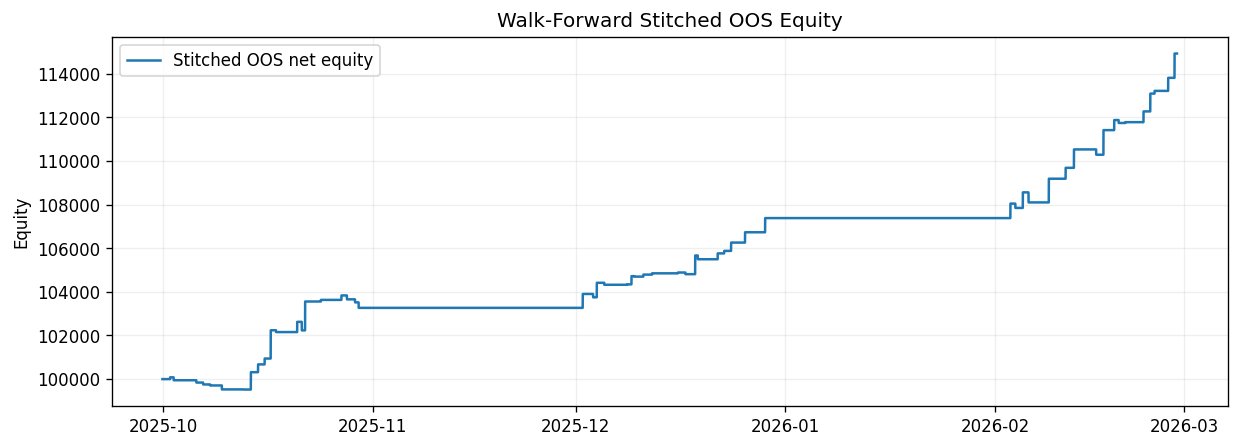

In [80]:
walk_forward_start = perf_counter()
walk_forward = run_recent_intrabar_walk_forward_analysis(context, replay_config)
walk_forward_elapsed = perf_counter() - walk_forward_start
print(f"Walk-forward runtime: {walk_forward_elapsed:.2f} seconds")

display(walk_forward.fold_summary)
display(walk_forward.parameter_stability)
display(walk_forward.optimization_results.head(12))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    walk_forward.oos_equity_curve["ts_event"],
    walk_forward.oos_equity_curve["net_equity"],
    label="Stitched OOS net equity",
)
ax.set_title("Walk-Forward Stitched OOS Equity")
ax.set_ylabel("Equity")
ax.grid(True, alpha=0.2)
ax.legend()
display(fig)
plt.close(fig)


## 14. Validation and Unit Tests

The notebook fails fast if the core temporal and bookkeeping checks break on the current minute sample.


In [81]:
display(result.validation_results)
assert (result.validation_results["status"] == "pass").all(), "One or more validation checks failed."


,test,status,detail
0,Trade timestamps are ordered,pass,Each trade exits at or after its entry timestamp.
1,Net equity reconciles to trade PnL,pass,Terminal net equity equals starting capital pl...
2,Session-close flattening,pass,No positions remain open at the final bar of a...
3,Exit events reconcile to closed trades,pass,The event log contains one exit event for each...
